In [1]:
#Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Extracting ZIP
import zipfile
zip_path = "/content/drive/My Drive/Customer Segmentation.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset/")

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [6]:
# Step 1: Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [7]:
# Step 2: Load Dataset
df = pd.read_csv("/content/dataset/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [8]:
# Step 3: Check Dataset Structure

print("Dataset Shape:")
print(df.shape)

print("\nDataset Information:")
df.info()

print("\nDataset Description:")
df.describe()

Dataset Shape:
(200, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

Dataset Description:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
# Step 4: Check Missing Values
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [10]:
# Step 5: Check Duplicate Records
df.duplicated().sum()

np.int64(0)

In [12]:
# Step 6: Check Dataset Labels
print(df.columns)

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


In [13]:
# Step 7: Remove Unnecessary Features
df.drop("CustomerID", axis=1, inplace=True)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [14]:
# Step 8: Encode Categorical Data
encoder = LabelEncoder()
df["Gender"] = encoder.fit_transform(df["Gender"])

df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


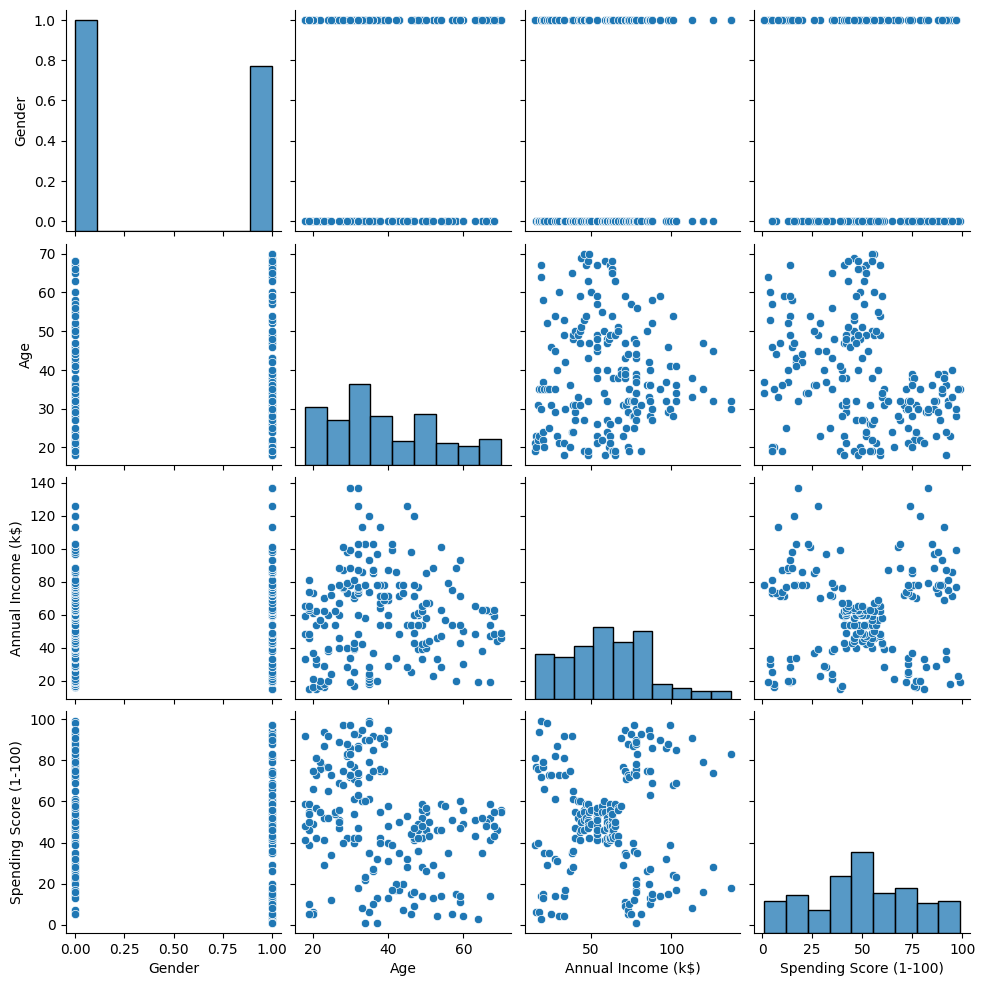

In [15]:
# Step 9: Data Visualization Before Training
sns.pairplot(df)
plt.show()

In [16]:
# Step 10: Feature Extraction
X = df.copy()
X.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [17]:
# Step 11: Data Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[ 1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [ 1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [-0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [-0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [-0.88640526, -0.56336851, -1.66266033, -0.39597992]])

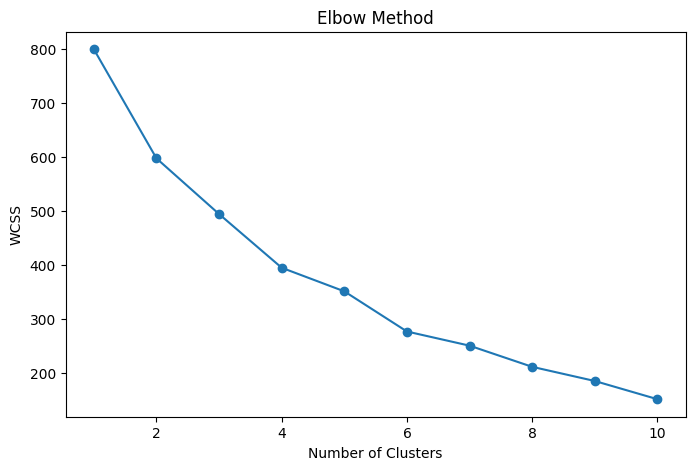

In [18]:
# Step 12: Find Optimal Clusters Using Elbow Method
wcss = []
for i in range(1,11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

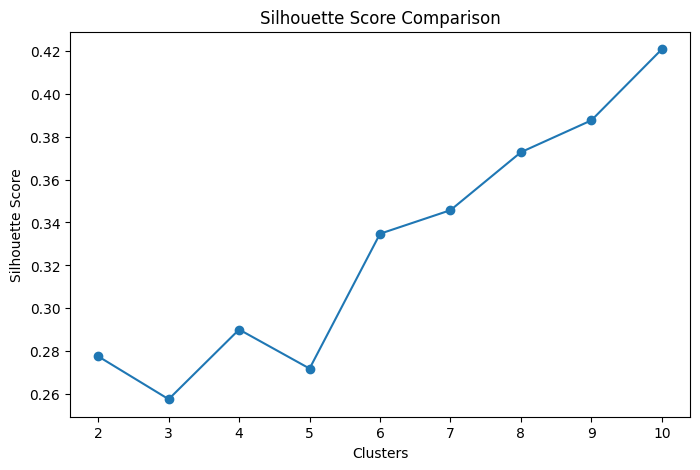

In [19]:
# Step 13: Silhouette Score Analysis
scores = []
for i in range(2,11):

    model = KMeans(
        n_clusters=i,
        random_state=42
    )

    labels = model.fit_predict(X_scaled)
    score = silhouette_score(
        X_scaled,
        labels
    )

    scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(
    range(2,11),
    scores,
    marker="o"
)

plt.xlabel("Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Comparison")
plt.show()

In [20]:
# Step 14: Train Final K-Means Model
optimal_clusters = 5
kmeans = KMeans(
    n_clusters=optimal_clusters,
    random_state=42
)

cluster_labels = kmeans.fit_predict(X_scaled)
df["Cluster"] = cluster_labels
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,19,15,39,2
1,1,21,15,81,2
2,0,20,16,6,4
3,0,23,16,77,4
4,0,31,17,40,4


In [21]:
# Step 15: Apply PCA for Dimension Reduction
pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(
    X_pca,
    columns=[
        "PCA1",
        "PCA2"
    ]
)

pca_df["Cluster"] = cluster_labels
pca_df.head()

,PCA1,PCA2,Cluster
0,-0.406383,-0.520714,2
1,-1.427673,-0.367310,2
2,0.050761,-1.894068,4
3,-1.694513,-1.631908,4
4,-0.313108,-1.810483,4


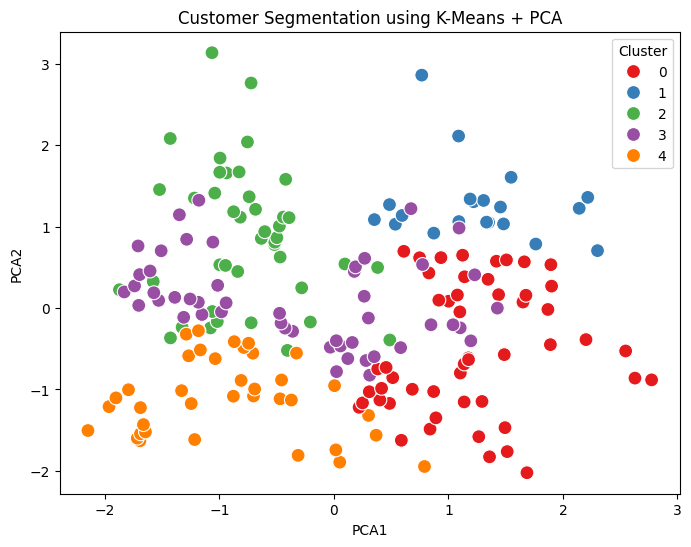

In [22]:
# Step 16: Visualize Customer Clusters
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set1",
    s=100
)

plt.title(
    "Customer Segmentation using K-Means + PCA"
)
plt.show()

In [23]:
# Step 17: Analyze Cluster Personas
persona = df.groupby("Cluster").mean()
persona

,Gender,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,
0,0.509804,56.470588,46.098039,39.313725
1,1.000000,39.500000,85.150000,14.050000
2,1.000000,28.690476,60.904762,70.238095
3,0.000000,37.897959,82.122449,54.448980
4,0.000000,27.315789,38.842105,56.210526


In [24]:
# Step 18: Create Business Personas
for cluster in persona.index:
    income = persona.loc[cluster,"Annual Income (k$)"]
    spending = persona.loc[cluster,"Spending Score (1-100)"]

    print("\nCluster:",cluster)
    if income > 60 and spending > 60:
        print("Persona: Premium Customers")
    elif income > 60 and spending < 40:
        print("Persona: High Income Low Spending Customers")
    elif income < 40 and spending > 60:
        print("Persona: Young Potential Customers")
    else:
        print("Persona: Budget Customers")


Cluster: 0
Persona: Budget Customers

Cluster: 1
Persona: High Income Low Spending Customers

Cluster: 2
Persona: Premium Customers

Cluster: 3
Persona: Budget Customers

Cluster: 4
Persona: Budget Customers


In [25]:
# Step 19: Test Model With New Customer Prediction
new_customer = np.array(
[
    [
        0,      # Gender encoded
        30,     # Age
        70,     # Income
        80      # Spending Score
    ]
])

new_customer_scaled = scaler.transform(
    new_customer
)

prediction = kmeans.predict(
    new_customer_scaled
)

print(
    "Customer belongs to Cluster:",
    prediction[0]
)

Customer belongs to Cluster: 3


In [26]:
# Step 20: Final Model Evaluation
final_score = silhouette_score(
    X_scaled,
    cluster_labels
)

print(
    "Silhouette Score:",
    final_score
)

print(
    "Model successfully created customer segments"
)

Silhouette Score: 0.27191023466188324
Model successfully created customer segments
